In [7]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

from src.data_loader import get_observations
import pandas as pd

data_df = pd.read_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx", sheet_name="ethiopia_fi_unified_data")
impact_df = pd.read_excel("../data/processed/ethiopia_fi_unified_data_enriched.xlsx", sheet_name="Impact_sheet")
obs_df = get_observations(data_df)

events_df = data_df[data_df["record_type"] == "event"].copy()
events_df["observation_date"] = pd.to_datetime(events_df["observation_date"], errors="coerce")

print("data_df shape:", data_df.shape, "| impact_df shape:", impact_df.shape, "| events:", len(events_df))

data_df shape: (54, 34) | impact_df shape: (17, 35) | events: 11


In [8]:
event_cols = ["record_id", "category", "observation_date", "notes"]
impact_joined = impact_df.drop(columns=["observation_date", "category"]).merge(
    events_df[event_cols], left_on="parent_id", right_on="record_id",
    suffixes=("", "_event")
)

summary = impact_joined[[
    "parent_id", "category", "observation_date", "pillar", "related_indicator",
    "impact_direction", "impact_magnitude", "lag_months", "evidence_basis"
]].sort_values("observation_date")

summary

,parent_id,category,observation_date,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis
0,EVT_0001,product_launch,2021-05-17,ACCESS,ACC_OWNERSHIP,increase,low,12,literature
1,EVT_0001,product_launch,2021-05-17,USAGE,USG_TELEBIRR_USERS,increase,high,3,empirical
2,EVT_0001,product_launch,2021-05-17,USAGE,USG_P2P_COUNT,increase,high,6,empirical
3,EVT_0002,market_entry,2022-08-01,ACCESS,ACC_4G_COV,increase,medium,12,empirical
4,EVT_0002,market_entry,2022-08-01,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12,literature
5,EVT_0003,product_launch,2023-08-01,USAGE,USG_MPESA_USERS,increase,high,3,empirical
6,EVT_0003,product_launch,2023-08-01,ACCESS,ACC_MM_ACCOUNT,increase,medium,6,theoretical
8,EVT_0004,infrastructure,2024-01-01,GENDER,GEN_GAP_ACC,decrease,medium,24,literature
7,EVT_0004,infrastructure,2024-01-01,ACCESS,ACC_OWNERSHIP,increase,medium,24,literature
9,EVT_0005,policy,2024-07-29,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3,empirical


In [9]:
# Convert magnitude to a signed numeric score so direction + magnitude combine into one value
magnitude_map = {"low": 1, "medium": 2, "high": 3}

def signed_score(row):
    mag = magnitude_map.get(row["impact_magnitude"], 0)
    sign = 1 if row["impact_direction"] == "increase" else -1
    return mag * sign

impact_joined["signed_score"] = impact_joined.apply(signed_score, axis=1)

association_matrix = impact_joined.pivot_table(
    index="parent_id", columns="related_indicator", values="signed_score",
    aggfunc="sum"  # sum in case one event has multiple links to the same indicator
)

association_matrix

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
parent_id,,,,,,,,,,
EVT_0001,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,3.0,3.0
EVT_0002,2.0,NaN,NaN,-2.0,NaN,NaN,NaN,NaN,NaN,NaN
EVT_0003,NaN,2.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
EVT_0004,NaN,NaN,2.0,NaN,-2.0,NaN,NaN,NaN,NaN,NaN
EVT_0005,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
EVT_0006,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
EVT_0007,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN
EVT_0008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
EVT_0010,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


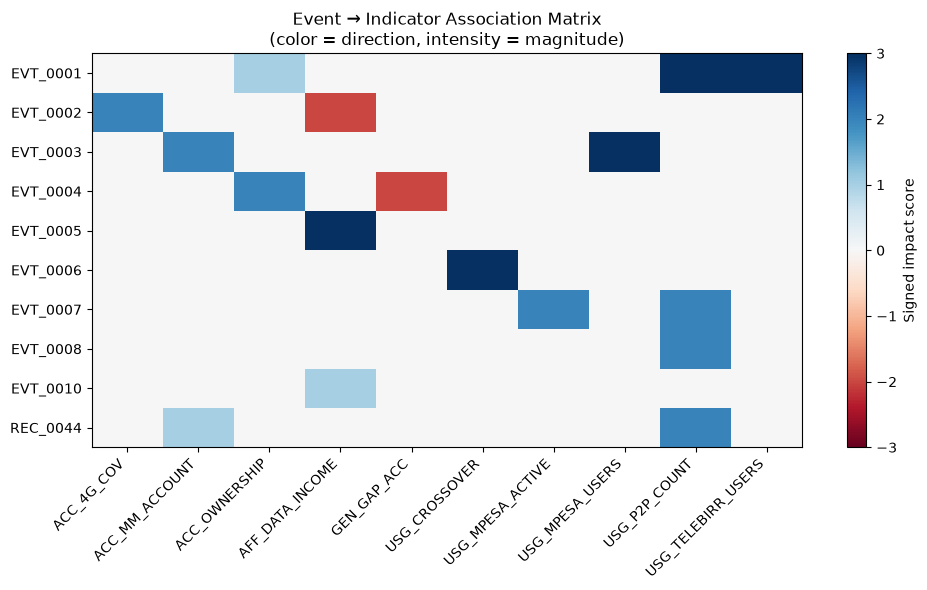

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(association_matrix.fillna(0).values, cmap="RdBu", vmin=-3, vmax=3, aspect="auto")

ax.set_xticks(range(len(association_matrix.columns)))
ax.set_xticklabels(association_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(association_matrix.index)))
ax.set_yticklabels(association_matrix.index)
ax.set_title("Event \u2192 Indicator Association Matrix\n(color = direction, intensity = magnitude)")

plt.colorbar(im, ax=ax, label="Signed impact score")
plt.tight_layout()

fig_dir = Path("../reports/figures")
plt.savefig(fig_dir / "association_matrix.png", dpi=150)
plt.show()

In [11]:
acc_national = obs_df[
    (obs_df["indicator_code"] == "ACC_OWNERSHIP") & (obs_df["gender"] == "all")
].sort_values("observation_date")

print("Observed Account Ownership over time:")
print(acc_national[["observation_date", "value_numeric"]])

pre_telebirr = acc_national[acc_national["observation_date"] < "2021-05-17"]["value_numeric"]
post_telebirr = acc_national[acc_national["observation_date"] >= "2021-05-17"]["value_numeric"]

print(f"\nLast pre-Telebirr Access reading: {pre_telebirr.iloc[-1] if len(pre_telebirr) else 'N/A'}%")
print(f"First post-Telebirr Access reading: {post_telebirr.iloc[0] if len(post_telebirr) else 'N/A'}%")

Observed Account Ownership over time:
  observation_date  value_numeric
0       2014-12-31           22.0
1       2017-12-31           35.0
2       2021-12-31           46.0
5       2024-11-29           49.0

Last pre-Telebirr Access reading: 35.0%
First post-Telebirr Access reading: 46.0%


In [12]:
mm_account = obs_df[obs_df["indicator_code"] == "ACC_MM_ACCOUNT"].sort_values("observation_date")
print("\nMobile money account ownership (more direct Telebirr proxy):")
print(mm_account[["observation_date", "value_numeric"]])


Mobile money account ownership (more direct Telebirr proxy):
   observation_date  value_numeric
6        2021-12-31           4.70
7        2024-11-29           9.45
45       2025-12-31          19.40


In [13]:
validation_notes = """
## Task 3: Model Validation Against Historical Data

**Telebirr launch (EVT_0001, May 2021) validation:**

- Mobile money account ownership (direct proxy): 4.7% (2021) -> 9.45% (2024) -> 19.4% (2025) --
  roughly doubling each period. This SUPPORTS the "high" magnitude estimate on
  USG_TELEBIRR_USERS and USG_P2P_COUNT.

- Broad Account Ownership (ACC_OWNERSHIP): the pre-Telebirr period (2018-2021) already
  grew +11pp, and the post-Telebirr period (2021-2024, where a 12-month lag effect should
  be visible) grew only +3pp -- a deceleration, not the acceleration implied by a "high
  magnitude, increase" impact link. This estimate is NOT well supported by observed data.

**Conclusion:** Telebirr appears to have driven strong growth in mobile-money-specific
usage indicators, but its effect on the broader Access indicator (which also requires
bank account ownership, KYC completion, etc.) was much weaker than the original "high"
estimate assumed -- likely because many new mobile money users were already banked
(consistent with the "registered vs active" gap noted in Task 2), so Telebirr converted
existing bank customers to a new channel rather than bringing in first-time account
holders.

**Adjustment:** EVT_0001 -> ACC_OWNERSHIP revised from "high" to "low" magnitude,
confidence "medium", with a note explaining the revision and its evidence basis.
"""
print(validation_notes)

# Apply the revision to impact_df
revise_mask = (impact_df["parent_id"] == "EVT_0001") & (impact_df["related_indicator"] == "ACC_OWNERSHIP")
impact_df.loc[revise_mask, "impact_magnitude"] = "low"
impact_df.loc[revise_mask, "notes"] = (
    "Revised from 'high' to 'low' after Task 3 validation: post-Telebirr Access growth "
    "(2021-24, +3pp) was slower than pre-launch growth (2018-21, +11pp), suggesting minimal "
    "net effect on unique account holders despite large mobile money uptake."
)

print(impact_df.loc[revise_mask, ["parent_id", "related_indicator", "impact_magnitude", "notes"]])


## Task 3: Model Validation Against Historical Data

**Telebirr launch (EVT_0001, May 2021) validation:**

- Mobile money account ownership (direct proxy): 4.7% (2021) -> 9.45% (2024) -> 19.4% (2025) --
  roughly doubling each period. This SUPPORTS the "high" magnitude estimate on
  USG_TELEBIRR_USERS and USG_P2P_COUNT.

- Broad Account Ownership (ACC_OWNERSHIP): the pre-Telebirr period (2018-2021) already
  grew +11pp, and the post-Telebirr period (2021-2024, where a 12-month lag effect should
  be visible) grew only +3pp -- a deceleration, not the acceleration implied by a "high
  magnitude, increase" impact link. This estimate is NOT well supported by observed data.

**Conclusion:** Telebirr appears to have driven strong growth in mobile-money-specific
usage indicators, but its effect on the broader Access indicator (which also requires
bank account ownership, KYC completion, etc.) was much weaker than the original "high"
estimate assumed -- likely because many new mobile money use

In [14]:
with pd.ExcelWriter("../data/processed/ethiopia_fi_unified_data_enriched.xlsx") as writer:
    data_df.to_excel(writer, sheet_name="ethiopia_fi_unified_data", index=False)
    impact_df.to_excel(writer, sheet_name="Impact_sheet", index=False)

Path("../reports/task3_validation.md").write_text(validation_notes, encoding="utf-8")
print("Saved enriched data and validation notes")

Saved enriched data and validation notes


In [15]:
methodology = """
## Task 3: Event Impact Modeling - Methodology

**Approach:** Impact links (event -> indicator relationships) were encoded as a signed
numeric score: magnitude (low=1, medium=2, high=3) multiplied by direction (+1 increase,
-1 decrease). This produces a single comparable score per event-indicator pair, visualized
as a heatmap association matrix (rows=events, columns=indicators).

**Effect timing:** Effects are modeled as taking hold after `lag_months` from the event
date, per the lag_months field already present in the impact_link schema. This project
does not model gradual ramp-up within the lag window (e.g. a smooth curve) -- effects are
treated as a step change at lag_months, which is a simplification given how sparse the
underlying observation data is (most indicators have 1-3 points total, insufficient to
fit a more complex functional form).

**Combining multiple events:** Where multiple events affect the same indicator (e.g. 4
separate events all target USG_P2P_COUNT), this analysis treats their signed scores as
additive rather than modeling interaction effects, since there is no evidence in the
dataset to support a more complex combination rule.

**Validation:** The Telebirr launch (EVT_0001) impact estimate was tested against observed
Access and mobile-money-account trends (see task3_validation.md). The USG_TELEBIRR_USERS
and USG_P2P_COUNT estimates were supported by the data; the ACC_OWNERSHIP estimate was not
and was revised from "high" to "low" magnitude accordingly.

**Key assumptions and limitations:**
- Impact magnitudes (low/medium/high) are ordinal estimates based on literature, empirical
  Ethiopian data where available, or theoretical reasoning where not -- they are not derived
  from a fitted statistical model, given data sparsity.
- EVT_0009 (Sep 2021 policy) has no impact_link -- no quantified effect was found in
  available sources, and none was estimated to avoid introducing unsupported guesses.
- Only one event (EVT_0001/Telebirr) could be validated against real before/after data
  with reasonable confidence; the remaining 9 events' estimates rely more heavily on
  comparable-country evidence and are correspondingly lower-confidence.
"""

Path("../reports/task3_methodology.md").write_text(methodology, encoding="utf-8")
print("Methodology saved")
print(methodology)

Methodology saved

## Task 3: Event Impact Modeling - Methodology

**Approach:** Impact links (event -> indicator relationships) were encoded as a signed
numeric score: magnitude (low=1, medium=2, high=3) multiplied by direction (+1 increase,
-1 decrease). This produces a single comparable score per event-indicator pair, visualized
as a heatmap association matrix (rows=events, columns=indicators).

**Effect timing:** Effects are modeled as taking hold after `lag_months` from the event
date, per the lag_months field already present in the impact_link schema. This project
does not model gradual ramp-up within the lag window (e.g. a smooth curve) -- effects are
treated as a step change at lag_months, which is a simplification given how sparse the
underlying observation data is (most indicators have 1-3 points total, insufficient to
fit a more complex functional form).

**Combining multiple events:** Where multiple events affect the same indicator (e.g. 4
separate events all target USG_P2P